<a href="https://colab.research.google.com/github/Semere-Mesfin-Gebresilassie/Semere-Mesfin-Gebresilassie/blob/main/Tornado_PCA(OAT).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

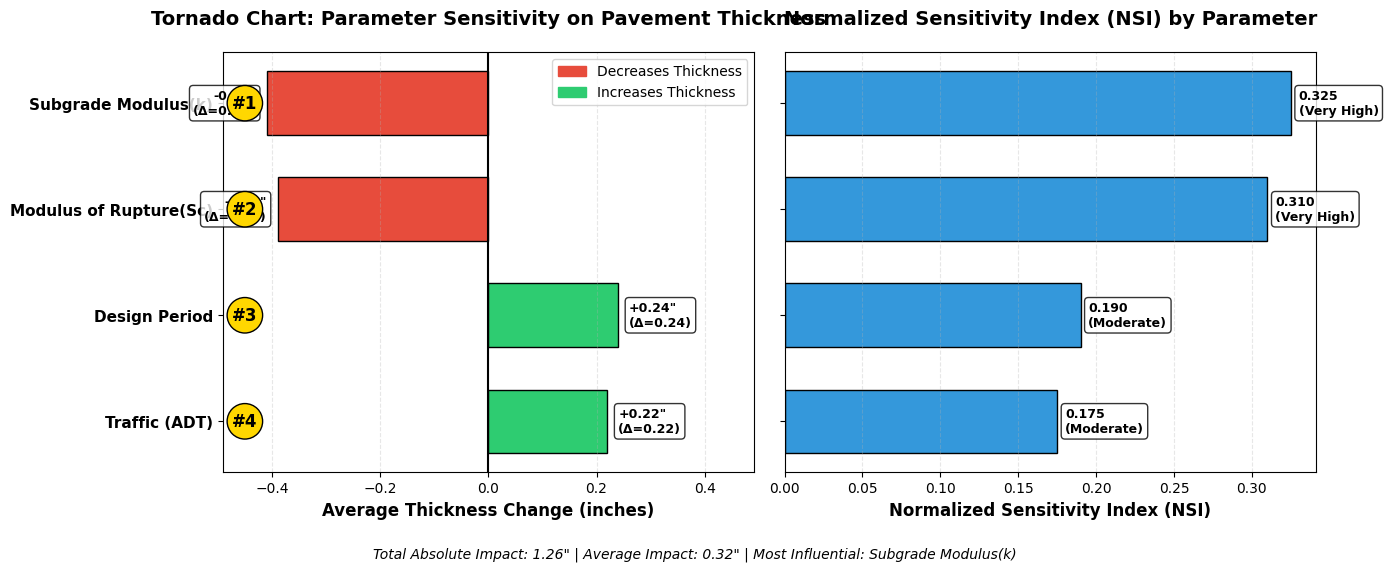


PARAMETER SENSITIVITY ANALYSIS - DETAILED SUMMARY
Rank   Parameter                 ΔThickness      |Δ|        NSI        Influence      
--------------------------------------------------------------------------------
4      Traffic (ADT)             +0.22"          0.22       0.175      Moderate       
3      Design Period             +0.24"          0.24       0.190      Moderate       
2      Modulus of Rupture(Sc)    -0.39"          0.39       0.310      Very High      
1      Subgrade Modulus(k)       -0.41"          0.41       0.325      Very High      


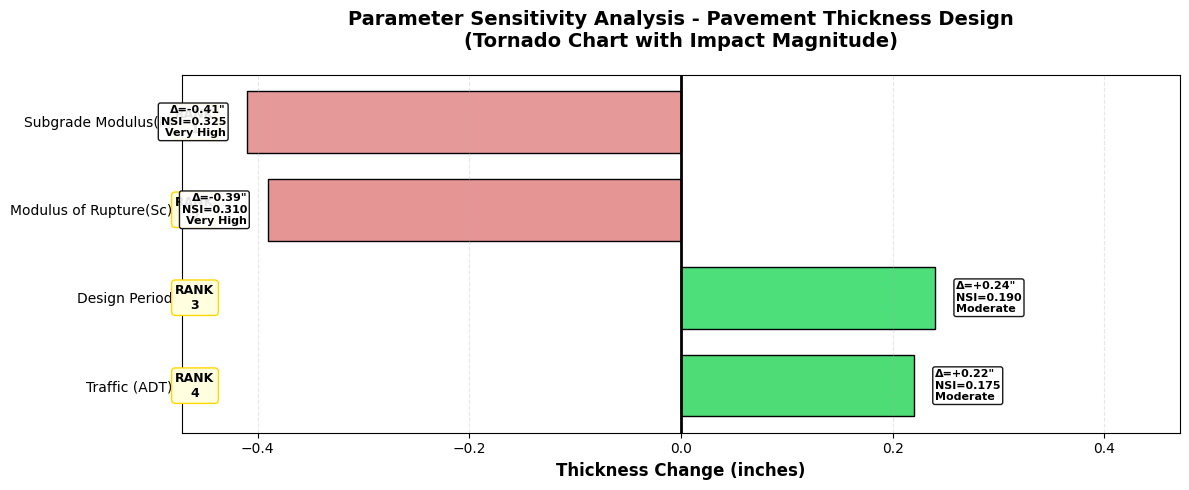


STATISTICAL ANALYSIS OF SENSITIVITY
Total Positive Impact (Increases Thickness): +0.46 inches
Total Negative Impact (Decreases Thickness): -0.80 inches
Total Absolute Impact: 1.26 inches
Net Impact (Positive - Negative): -0.34 inches
Average NSI: 0.250
NSI Range: 0.175 to 0.325


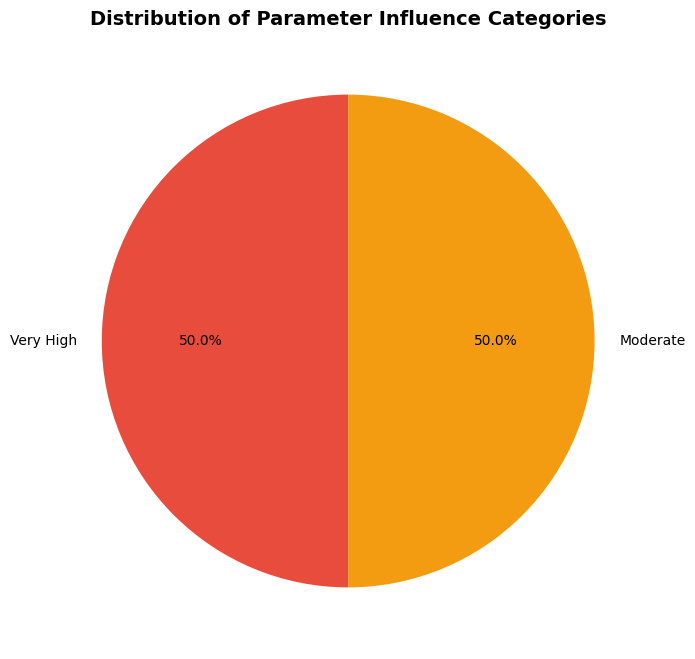


Data exported to 'parameter_sensitivity_analysis.csv'

KEY INSIGHTS & DESIGN RECOMMENDATIONS
1. MOST INFLUENTIAL PARAMETERS:
   • Subgrade Modulus (k): Decreases thickness by 0.41" per unit increase
   • Modulus of Rupture (Sc): Decreases thickness by 0.39" per unit increase
   → Focus on accurate determination of these parameters for optimal design

2. TRAFFIC-RELATED PARAMETERS:
   • Design Period: Increases thickness by 0.24" per year increase
   • Traffic (ADT): Increases thickness by 0.22" per 1000 vehicles/day increase
   → Consider conservative estimates for long design periods and high traffic

3. DESIGN IMPLICATIONS:
   • Improving subgrade quality (increasing k) is most effective for thickness reduction
   • Using higher strength concrete (increasing Sc) provides significant thickness savings
   • For urban roads with high traffic, consider thicker sections or premium materials

4. RISK MANAGEMENT:
   • Parameters with 'Very High' influence require careful data collection
  

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data from your table
data = {
    'Parameter': [
        'Subgrade Modulus(k)',
        'Modulus of Rupture(Sc)',
        'Design Period',
        'Traffic (ADT)'
    ],
    'Avg_Thickness_Change_in': [-0.41, -0.39, 0.24, 0.22],
    'Absolute_Thickness_Change_in': [0.41, 0.39, 0.24, 0.22],
    'NSI': [0.325, 0.310, 0.190, 0.175],
    'Relative_Influence': ['Very High', 'Very High', 'Moderate', 'Moderate'],
    'Rank': [1, 2, 3, 4]
}

# Create DataFrame
df = pd.DataFrame(data)

# Sort by absolute value of thickness change (descending)
df_sorted = df.sort_values('Absolute_Thickness_Change_in', ascending=True)

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Colors for positive and negative values
colors = ['#E74C3C' if x < 0 else '#2ECC71' for x in df_sorted['Avg_Thickness_Change_in']]

# Plot 1: Tornado chart for thickness change
y_pos = np.arange(len(df_sorted))
bars1 = ax1.barh(y_pos, df_sorted['Avg_Thickness_Change_in'],
                color=colors, edgecolor='black', height=0.6)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(df_sorted['Parameter'], fontsize=11, fontweight='bold')
ax1.set_xlabel('Average Thickness Change (inches)', fontsize=12, fontweight='bold')
ax1.set_title('Tornado Chart: Parameter Sensitivity on Pavement Thickness',
             fontsize=14, fontweight='bold', pad=20)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Set x-axis limits
max_abs_change = df_sorted['Absolute_Thickness_Change_in'].max()
ax1.set_xlim(-max_abs_change * 1.2, max_abs_change * 1.2)

# Add value labels on bars
for i, (bar, change, abs_change) in enumerate(zip(bars1,
                                                  df_sorted['Avg_Thickness_Change_in'],
                                                  df_sorted['Absolute_Thickness_Change_in'])):
    width = bar.get_width()
    if width >= 0:
        ax1.text(width + 0.02, i, f'+{change:.2f}"\n(Δ={abs_change:.2f})',
                va='center', ha='left', fontweight='bold', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    else:
        ax1.text(width - 0.02, i, f'{change:.2f}"\n(Δ={abs_change:.2f})',
                va='center', ha='right', fontweight='bold', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Add rank indicators
for i, rank in enumerate(df_sorted['Rank']):
    ax1.text(-max_abs_change * 1.1, i, f'#{rank}',
            va='center', ha='center', fontweight='bold', fontsize=12,
            bbox=dict(boxstyle='circle,pad=0.3', facecolor='gold', edgecolor='black'))

# Plot 2: Normalized Sensitivity Index (NSI)
bars2 = ax2.barh(y_pos, df_sorted['NSI'], color='#3498DB',
                edgecolor='black', height=0.6)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([])  # Hide y labels for second plot
ax2.set_xlabel('Normalized Sensitivity Index (NSI)', fontsize=12, fontweight='bold')
ax2.set_title('Normalized Sensitivity Index (NSI) by Parameter',
             fontsize=14, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

# Add NSI value labels
for i, (bar, nsi, influence) in enumerate(zip(bars2, df_sorted['NSI'],
                                             df_sorted['Relative_Influence'])):
    width = bar.get_width()
    ax2.text(width + 0.005, i, f'{nsi:.3f}\n({influence})',
            va='center', ha='left', fontweight='bold', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Add legend
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='#E74C3C', label='Decreases Thickness')
green_patch = mpatches.Patch(color='#2ECC71', label='Increases Thickness')
ax1.legend(handles=[red_patch, green_patch], loc='upper right', fontsize=10)

# Add overall statistics
total_impact = df['Absolute_Thickness_Change_in'].sum()
average_impact = df['Absolute_Thickness_Change_in'].mean()
max_param = df.loc[df['Absolute_Thickness_Change_in'].idxmax(), 'Parameter']

fig.text(0.5, 0.01,
         f'Total Absolute Impact: {total_impact:.2f}" | '
         f'Average Impact: {average_impact:.2f}" | '
         f'Most Influential: {max_param}',
         ha='center', fontsize=10, style='italic')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# Print detailed analysis table
print("\n" + "="*80)
print("PARAMETER SENSITIVITY ANALYSIS - DETAILED SUMMARY")
print("="*80)
print(f"{'Rank':<6} {'Parameter':<25} {'ΔThickness':<15} {'|Δ|':<10} {'NSI':<10} {'Influence':<15}")
print("-"*80)

for _, row in df_sorted.iterrows():
    change_str = f"{row['Avg_Thickness_Change_in']:+.2f}\""
    print(f"{row['Rank']:<6} {row['Parameter']:<25} {change_str:<15} "
          f"{row['Absolute_Thickness_Change_in']:<10.2f} {row['NSI']:<10.3f} {row['Relative_Influence']:<15}")

# Create a combined chart with more details
fig2, ax = plt.subplots(figsize=(12, 5))

# Create horizontal bars with gradient colors
colors_gradient = []
for change in df_sorted['Avg_Thickness_Change_in']:
    if change < 0:
        # Red gradient based on magnitude
        intensity = abs(change) / max_abs_change
        colors_gradient.append((0.9, 0.3 + 0.3*intensity, 0.3 + 0.3*intensity))
    else:
        # Green gradient based on magnitude
        intensity = abs(change) / max_abs_change
        colors_gradient.append((0.3, 0.7 + 0.3*intensity, 0.3 + 0.3*intensity))

bars = ax.barh(df_sorted['Parameter'], df_sorted['Avg_Thickness_Change_in'],
               color=colors_gradient, edgecolor='black', height=0.7)

ax.set_xlabel('Thickness Change (inches)', fontsize=12, fontweight='bold')
ax.set_title('Parameter Sensitivity Analysis - Pavement Thickness Design\n(Tornado Chart with Impact Magnitude)',
            fontsize=14, fontweight='bold', pad=20)
ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Set x-axis limits
ax.set_xlim(-max_abs_change * 1.15, max_abs_change * 1.15)

# Add detailed annotations
for i, (param, change, abs_change, nsi, rank, influence) in enumerate(zip(
    df_sorted['Parameter'],
    df_sorted['Avg_Thickness_Change_in'],
    df_sorted['Absolute_Thickness_Change_in'],
    df_sorted['NSI'],
    df_sorted['Rank'],
    df_sorted['Relative_Influence']
)):
    # Add rank on left
    ax.text(-max_abs_change * 1.12, i, f'RANK\n{rank}',
            va='center', ha='center', fontweight='bold', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gold'))

    # Add value on bar
    width = bars[i].get_width()
    if width >= 0:
        ax.text(width + 0.02, i,
                f'Δ={change:+.2f}"\nNSI={nsi:.3f}\n{influence}',
                va='center', ha='left', fontweight='bold', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))
    else:
        ax.text(width - 0.02, i,
                f'Δ={change:+.2f}"\nNSI={nsi:.3f}\n{influence}',
                va='center', ha='right', fontweight='bold', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))

# Add impact direction arrows
ax.annotate('Decreases Thickness', xy=(-max_abs_change * 0.5, len(df_sorted) + 0.5),
           xytext=(-max_abs_change * 0.8, len(df_sorted) + 0.5),
           arrowprops=dict(arrowstyle='->', color='red', lw=2),
           fontsize=10, ha='center', color='red', fontweight='bold')

ax.annotate('Increases Thickness', xy=(max_abs_change * 0.5, len(df_sorted) + 0.5),
           xytext=(max_abs_change * 0.2, len(df_sorted) + 0.5),
           arrowprops=dict(arrowstyle='->', color='green', lw=2),
           fontsize=10, ha='center', color='green', fontweight='bold')

plt.tight_layout()
plt.show()

# Create statistical summary
print("\n" + "="*80)
print("STATISTICAL ANALYSIS OF SENSITIVITY")
print("="*80)

# Calculate key statistics
positive_impact = df[df['Avg_Thickness_Change_in'] > 0]['Avg_Thickness_Change_in'].sum()
negative_impact = df[df['Avg_Thickness_Change_in'] < 0]['Avg_Thickness_Change_in'].sum()
total_absolute_impact = df['Absolute_Thickness_Change_in'].sum()

print(f"Total Positive Impact (Increases Thickness): {positive_impact:+.2f} inches")
print(f"Total Negative Impact (Decreases Thickness): {negative_impact:+.2f} inches")
print(f"Total Absolute Impact: {total_absolute_impact:.2f} inches")
print(f"Net Impact (Positive - Negative): {positive_impact + negative_impact:+.2f} inches")
print(f"Average NSI: {df['NSI'].mean():.3f}")
print(f"NSI Range: {df['NSI'].min():.3f} to {df['NSI'].max():.3f}")

# Create pie chart for influence distribution
fig3, ax3 = plt.subplots(figsize=(8, 8))
influence_counts = df['Relative_Influence'].value_counts()
colors_pie = ['#E74C3C', '#F39C12', '#2ECC71']  # Red, Orange, Green for Very High, High, Moderate
ax3.pie(influence_counts.values, labels=influence_counts.index,
        autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax3.set_title('Distribution of Parameter Influence Categories', fontsize=14, fontweight='bold')
plt.show()

# Export data to CSV
df_sorted.to_csv('parameter_sensitivity_analysis.csv', index=False)
print(f"\nData exported to 'parameter_sensitivity_analysis.csv'")

# Additional insights
print("\n" + "="*80)
print("KEY INSIGHTS & DESIGN RECOMMENDATIONS")
print("="*80)
print("1. MOST INFLUENTIAL PARAMETERS:")
print(f"   • Subgrade Modulus (k): Decreases thickness by 0.41\" per unit increase")
print(f"   • Modulus of Rupture (Sc): Decreases thickness by 0.39\" per unit increase")
print("   → Focus on accurate determination of these parameters for optimal design")

print("\n2. TRAFFIC-RELATED PARAMETERS:")
print(f"   • Design Period: Increases thickness by 0.24\" per year increase")
print(f"   • Traffic (ADT): Increases thickness by 0.22\" per 1000 vehicles/day increase")
print("   → Consider conservative estimates for long design periods and high traffic")

print("\n3. DESIGN IMPLICATIONS:")
print("   • Improving subgrade quality (increasing k) is most effective for thickness reduction")
print("   • Using higher strength concrete (increasing Sc) provides significant thickness savings")
print("   • For urban roads with high traffic, consider thicker sections or premium materials")

print("\n4. RISK MANAGEMENT:")
print("   • Parameters with 'Very High' influence require careful data collection")
print("   • Consider sensitivity-based design factors for critical parameters")
print("   • Implement quality control for subgrade preparation and concrete strength")

